# 0_1. Odległości, macierze sąsiedztwa i graf kNN — ręcznie

Ten notebook jest fundamentem dla **KNN**, **DBSCAN** i **UMAP**.

Wszystkie te metody zaczynają od pytania:

> które punkty są blisko siebie?

Będziemy używać sześciu punktów `A, B, C, D, E, F`, żeby ręcznie zobaczyć:

1. jak powstaje macierz odległości,
2. jak z odległości zrobić macierz sąsiedztwa,
3. czym różni się graf `eps` od grafu `kNN`,
4. dlaczego symetryzacja grafu kNN może stworzyć zaskakujące połączenia między grupami.


## Jak prowadzić ten notebook?

Najpierw nie mówimy jeszcze o algorytmach. Zaczynamy od jednego pytania:

> Mamy punkty. Jak komputer ma zdecydować, które punkty są do siebie podobne?

Cała ścieżka jest taka:

```text
punkty → odległości → sąsiedztwo → graf → algorytmy
```

Dopiero później pokażemy, że z tej samej idei korzystają **KNN**, **DBSCAN**, **UMAP**, **t-SNE** i metody grafowe.


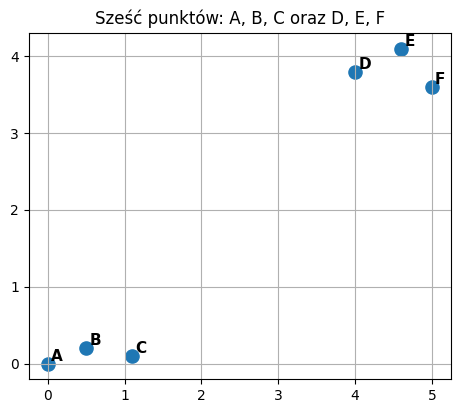

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from IPython.display import display, Markdown

np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.precision', 3)
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

def pairwise_distances(X):
    X = np.asarray(X, dtype=float)
    diff = X[:, None, :] - X[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))

def show_df(M, labels=None, columns=None, precision=3):
    if labels is None:
        labels = range(len(M))
    if columns is None:
        columns = labels
    return pd.DataFrame(np.round(M, precision), index=labels, columns=columns)

def show_matrix(M, labels, title, fmt='.2f', cmap='viridis', vmin=None, vmax=None, figsize=(4.6,4.0)):
    df = pd.DataFrame(M, index=labels, columns=labels)
    display(df.style.format(fmt))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            if fmt == '.0f':
                txt = f'{M[i,j]:.0f}'
            elif fmt == '.1f':
                txt = f'{M[i,j]:.1f}'
            else:
                txt = f'{M[i,j]:.2f}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

def plot_points(X, labels, y=None, title='punkty', annotate=True, ax=None, extra_points=None):
    X = np.asarray(X, dtype=float)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4.5))
    if y is None:
        ax.scatter(X[:,0], X[:,1], s=90)
    else:
        y = np.asarray(y)
        for val in np.unique(y):
            mask = y == val
            ax.scatter(X[mask,0], X[mask,1], s=90, label=f'klasa {val}')
        ax.legend()
    if annotate:
        for lab, (xv,yv) in zip(labels, X):
            ax.text(xv+0.04, yv+0.04, str(lab), fontsize=11, weight='bold')
    if extra_points:
        for lab, pt in extra_points.items():
            ax.scatter([pt[0]], [pt[1]], marker='*', s=160)
            ax.text(pt[0]+0.06, pt[1]+0.06, lab, fontsize=12, weight='bold')
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    return ax

def plot_graph(X, labels, A, title='', directed=False, ax=None):
    X = np.asarray(X, dtype=float)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4.5))
    ax.scatter(X[:,0], X[:,1], s=120)
    for i, lab in enumerate(labels):
        ax.text(X[i,0]+0.04, X[i,1]+0.04, str(lab), fontsize=11, weight='bold')
    n = len(labels)
    for i in range(n):
        for j in range(n):
            if i == j or A[i,j] == 0:
                continue
            if not directed and j < i:
                continue
            x1,y1 = X[i]; x2,y2 = X[j]
            if directed:
                ax.annotate('', xy=(x2,y2), xytext=(x1,y1), arrowprops=dict(arrowstyle='->', alpha=0.45, lw=1.2))
            else:
                ax.plot([x1,x2], [y1,y2], alpha=0.45)
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    return ax

labels = np.array(list('ABCDEF'))
X = np.array([
    [0.0, 0.0],   # A
    [0.5, 0.2],   # B
    [1.1, 0.1],   # C
    [4.0, 3.8],   # D
    [4.6, 4.1],   # E
    [5.0, 3.6],   # F
])
plot_points(X, labels, title='Sześć punktów: A, B, C oraz D, E, F')
plt.show()


## 1. Macierz odległości

Dla punktów w 2D używamy odległości euklidesowej:

$$
d(x_i,x_j)=\sqrt{(x_{i1}-x_{j1})^2+(x_{i2}-x_{j2})^2}.
$$

Przykład:

$$
A=(0,0), \qquad B=(0.5,0.2)
$$

$$
d(A,B)=\sqrt{(0-0.5)^2+(0-0.2)^2}
=\sqrt{0.25+0.04}
=\sqrt{0.29}\approx 0.54.
$$


,A,B,C,D,E,F
A,.2f,.2f,.2f,.2f,.2f,.2f
B,.2f,.2f,.2f,.2f,.2f,.2f
C,.2f,.2f,.2f,.2f,.2f,.2f
D,.2f,.2f,.2f,.2f,.2f,.2f
E,.2f,.2f,.2f,.2f,.2f,.2f
F,.2f,.2f,.2f,.2f,.2f,.2f


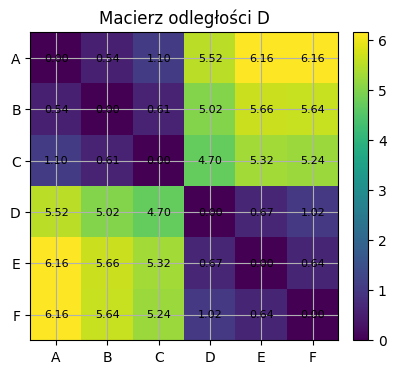

In [2]:
D = pairwise_distances(X)
show_matrix(D, labels, 'Macierz odległości D', fmt='.2f', cmap='viridis')

### Czy sama macierz odległości jest już grafem?

Jeszcze nie.

Macierz odległości mówi tylko **jak daleko** są punkty od siebie. Żeby dostać graf, musimy podjąć dodatkową decyzję:

> kiedy dwa punkty uznajemy za sąsiadów?

Są dwa najprostsze pomysły:

1. **promień $\varepsilon$** — łączymy punkty, jeśli są bliżej niż zadany próg,
2. **$k$ najbliższych sąsiadów** — każdy punkt wybiera dokładnie $k$ najbliższych punktów.

To przejście jest kluczowe: **algorytm nie dostaje grafu za darmo — graf powstaje z decyzji o sąsiedztwie**.


## 2. Pierwsza macierz sąsiedztwa: promień $\varepsilon$

Najprostszy pomysł:

$$
A_{ij}=\begin{cases}
1, & 0<d(x_i,x_j)\leq \varepsilon,\\
0, & \text{w przeciwnym razie.}
\end{cases}
$$

Czyli: stawiamy `1`, jeśli dwa punkty są w promieniu $\varepsilon$.  
Na przekątnej dajemy `0`, bo zwykle nie rysujemy krawędzi punktu do samego siebie.


,A,B,C,D,E,F
A,.0f,.0f,.0f,.0f,.0f,.0f
B,.0f,.0f,.0f,.0f,.0f,.0f
C,.0f,.0f,.0f,.0f,.0f,.0f
D,.0f,.0f,.0f,.0f,.0f,.0f
E,.0f,.0f,.0f,.0f,.0f,.0f
F,.0f,.0f,.0f,.0f,.0f,.0f


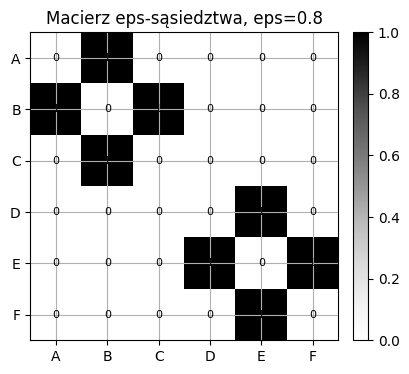

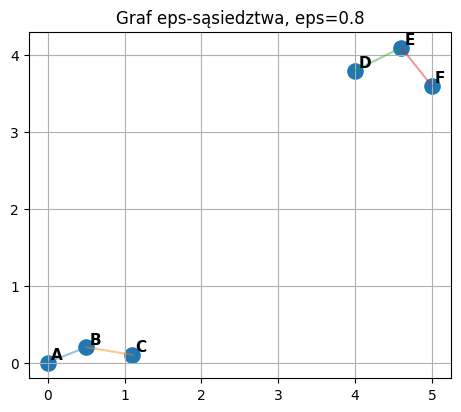

,A,B,C,D,E,F
A,.0f,.0f,.0f,.0f,.0f,.0f
B,.0f,.0f,.0f,.0f,.0f,.0f
C,.0f,.0f,.0f,.0f,.0f,.0f
D,.0f,.0f,.0f,.0f,.0f,.0f
E,.0f,.0f,.0f,.0f,.0f,.0f
F,.0f,.0f,.0f,.0f,.0f,.0f


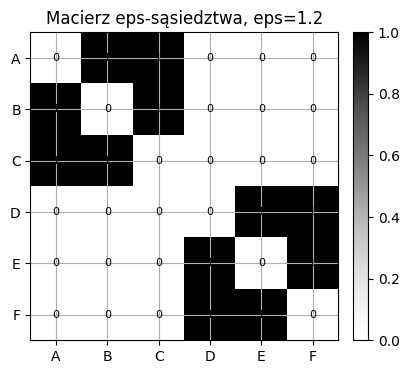

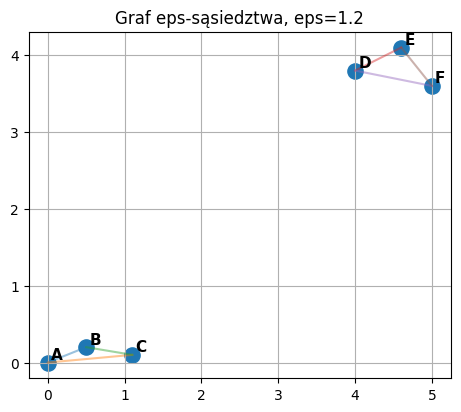

,A,B,C,D,E,F
A,.0f,.0f,.0f,.0f,.0f,.0f
B,.0f,.0f,.0f,.0f,.0f,.0f
C,.0f,.0f,.0f,.0f,.0f,.0f
D,.0f,.0f,.0f,.0f,.0f,.0f
E,.0f,.0f,.0f,.0f,.0f,.0f
F,.0f,.0f,.0f,.0f,.0f,.0f


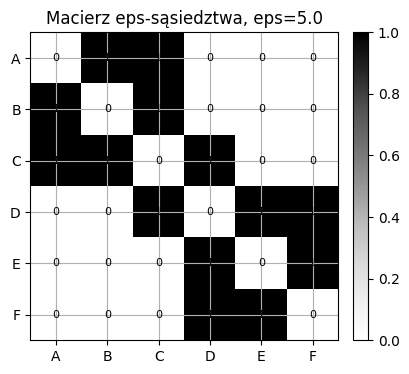

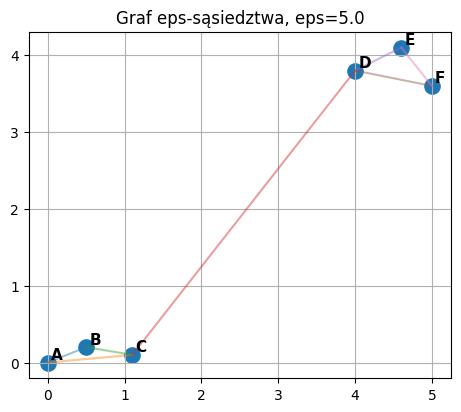

In [3]:
def adjacency_eps(D, eps):
    A = ((D <= eps) & (D > 0)).astype(int)
    return A

for eps in [0.8, 1.2, 5.0]:
    A_eps = adjacency_eps(D, eps)
    show_matrix(A_eps, labels, f'Macierz eps-sąsiedztwa, eps={eps}', fmt='.0f', cmap='Greys', vmin=0, vmax=1)
    plot_graph(X, labels, A_eps, title=f'Graf eps-sąsiedztwa, eps={eps}', directed=False)
    plt.show()

### Co pokazało $\varepsilon$-sąsiedztwo?

Dla małego $\varepsilon$ dostajemy tylko bardzo lokalne połączenia. Dla dużego $\varepsilon$ graf szybko zaczyna łączyć odległe grupy.

To jest dokładnie intuicja potrzebna później w **DBSCAN**:

```text
małe eps  → punkty widzą tylko najbliższe otoczenie
duże eps  → różne skupiska mogą się sztucznie połączyć
```

Wniosek dydaktyczny: parametr $\varepsilon$ nie jest tylko technicznym suwakiem. On definiuje, **co znaczy lokalność**.


## 3. Macierz kNN: każdy punkt wybiera $k$ najbliższych sąsiadów

W grafie kNN robimy coś innego niż przy $\varepsilon$.

Dla każdego punktu `i` sortujemy inne punkty po odległości i wybieramy pierwsze $k$:

$$
A_{ij}=1
\quad\Longleftrightarrow\quad
x_j \text{ należy do } k \text{ najbliższych sąsiadów } x_i.
$$

Uwaga: taka macierz jest **kierunkowa**.  
Może być tak, że `A` wybiera `B`, ale `B` nie wybiera `A`.


In [4]:
def knn_adjacency(D, k):
    n = D.shape[0]
    A = np.zeros((n, n), dtype=int)
    for i in range(n):
        order = np.argsort(D[i])
        neighbors = [j for j in order if j != i][:k]
        A[i, neighbors] = 1
    return A

def knn_table(D, labels, k):
    rows = []
    for i, lab in enumerate(labels):
        order = [j for j in np.argsort(D[i]) if j != i][:k]
        rows.append({
            'punkt': lab,
            **{f'{r+1}. sąsiad': labels[j] for r,j in enumerate(order)},
            **{f'do {labels[j]}': round(D[i,j], 3) for r,j in enumerate(order)}
        })
    return pd.DataFrame(rows).set_index('punkt')

for k in [1,2,3]:
    print(f'k={k}: najbliżsi sąsiedzi')
    display(knn_table(D, labels, k))

k=1: najbliżsi sąsiedzi


,1. sąsiad,do B,do A,do E,do F
punkt,,,,,
A,B,0.539,NaN,NaN,NaN
B,A,NaN,0.539,NaN,NaN
C,B,0.608,NaN,NaN,NaN
D,E,NaN,NaN,0.671,NaN
E,F,NaN,NaN,NaN,0.64
F,E,NaN,NaN,0.640,NaN


k=2: najbliżsi sąsiedzi


,1. sąsiad,2. sąsiad,do B,do C,do A,do E,do F,do D
punkt,,,,,,,,
A,B,C,0.539,1.105,NaN,NaN,NaN,NaN
B,A,C,NaN,0.608,0.539,NaN,NaN,NaN
C,B,A,0.608,NaN,1.105,NaN,NaN,NaN
D,E,F,NaN,NaN,NaN,0.671,1.02,NaN
E,F,D,NaN,NaN,NaN,NaN,0.64,0.671
F,E,D,NaN,NaN,NaN,0.640,NaN,1.020


k=3: najbliżsi sąsiedzi


,1. sąsiad,2. sąsiad,3. sąsiad,do B,do C,do D,do A,do E,do F
punkt,,,,,,,,,
A,B,C,D,0.539,1.105,5.517,NaN,NaN,NaN
B,A,C,D,NaN,0.608,5.021,0.539,NaN,NaN
C,B,A,D,0.608,NaN,4.701,1.105,NaN,NaN
D,E,F,C,NaN,4.701,NaN,NaN,0.671,1.02
E,F,D,C,NaN,5.315,0.671,NaN,NaN,0.64
F,E,D,C,NaN,5.240,1.020,NaN,0.640,NaN


## 4. Kierunkowa macierz kNN

W tej wersji każdy wiersz ma dokładnie $k$ jedynek.

Interpretacja wiersza:

> wiersz `A` mówi, kogo punkt `A` wskazuje jako swoich sąsiadów.


,A,B,C,D,E,F
A,.0f,.0f,.0f,.0f,.0f,.0f
B,.0f,.0f,.0f,.0f,.0f,.0f
C,.0f,.0f,.0f,.0f,.0f,.0f
D,.0f,.0f,.0f,.0f,.0f,.0f
E,.0f,.0f,.0f,.0f,.0f,.0f
F,.0f,.0f,.0f,.0f,.0f,.0f


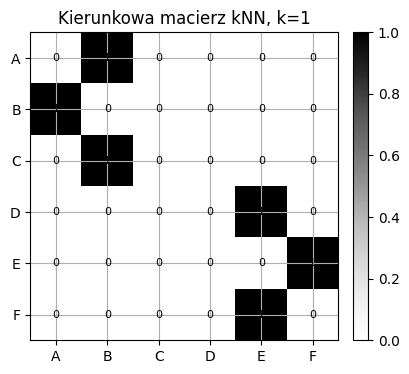

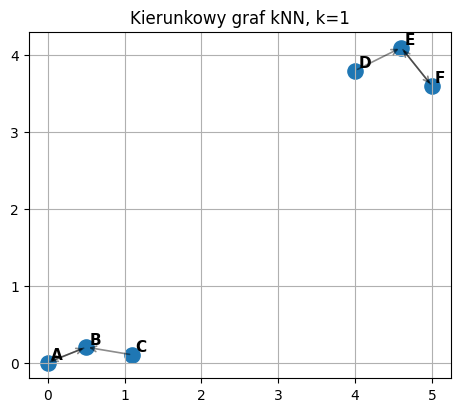

,A,B,C,D,E,F
A,.0f,.0f,.0f,.0f,.0f,.0f
B,.0f,.0f,.0f,.0f,.0f,.0f
C,.0f,.0f,.0f,.0f,.0f,.0f
D,.0f,.0f,.0f,.0f,.0f,.0f
E,.0f,.0f,.0f,.0f,.0f,.0f
F,.0f,.0f,.0f,.0f,.0f,.0f


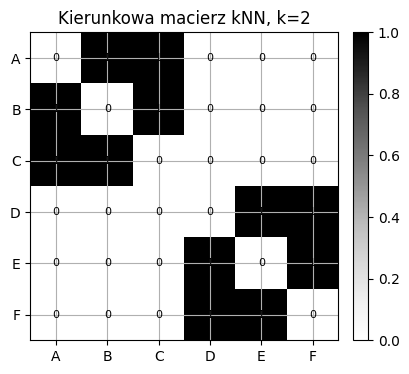

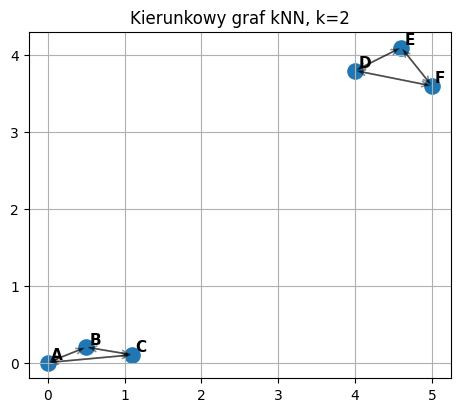

,A,B,C,D,E,F
A,.0f,.0f,.0f,.0f,.0f,.0f
B,.0f,.0f,.0f,.0f,.0f,.0f
C,.0f,.0f,.0f,.0f,.0f,.0f
D,.0f,.0f,.0f,.0f,.0f,.0f
E,.0f,.0f,.0f,.0f,.0f,.0f
F,.0f,.0f,.0f,.0f,.0f,.0f


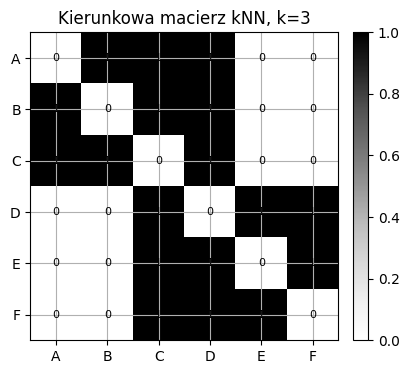

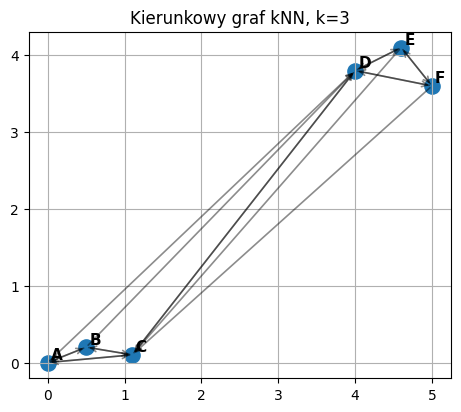

In [5]:
for k in [1,2,3]:
    A_knn = knn_adjacency(D, k)
    show_matrix(A_knn, labels, f'Kierunkowa macierz kNN, k={k}', fmt='.0f', cmap='Greys', vmin=0, vmax=1)
    plot_graph(X, labels, A_knn, title=f'Kierunkowy graf kNN, k={k}', directed=True)
    plt.show()

### Sprawdźmy asymetrię kNN

Macierz kNN jest kierunkowa, bo pytanie brzmi:

> czy $x_j$ należy do listy najbliższych sąsiadów punktu $x_i$?

To nie musi oznaczać, że $x_i$ należy do listy najbliższych sąsiadów punktu $x_j$.

Poniższa komórka wypisuje pary, dla których zachodzi tylko jedna z relacji: `A → B` albo `B → A`.


In [6]:
def asymmetric_knn_pairs(A, labels):
    rows = []
    n = A.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] != A[j, i]:
                if A[i, j] == 1:
                    rows.append({'para': f'{labels[i]}–{labels[j]}', 'relacja': f'{labels[i]} → {labels[j]}', 'odwrotnie?': 'nie'})
                else:
                    rows.append({'para': f'{labels[i]}–{labels[j]}', 'relacja': f'{labels[j]} → {labels[i]}', 'odwrotnie?': 'nie'})
    return pd.DataFrame(rows)

for k in [1, 2, 3]:
    A_dir = knn_adjacency(D, k)
    print(f'Asymetryczne relacje dla k={k}')
    asym = asymmetric_knn_pairs(A_dir, labels)
    if len(asym) == 0:
        display(Markdown('Brak asymetrycznych relacji — ta konkretna macierz jest już symetryczna.'))
    else:
        display(asym)


Asymetryczne relacje dla k=1


,para,relacja,odwrotnie?
0,B–C,C → B,nie
1,D–E,D → E,nie


Asymetryczne relacje dla k=2


Brak asymetrycznych relacji — ta konkretna macierz jest już symetryczna.

Asymetryczne relacje dla k=3


,para,relacja,odwrotnie?
0,A–D,A → D,nie
1,B–D,B → D,nie
2,C–E,E → C,nie
3,C–F,F → C,nie


## 5. Symetryzacja: dwa różne warianty

Często chcemy graf bez kierunku. Są dwa popularne sposoby.

### Wariant 1: union / OR

Łączymy punkty, jeśli **chociaż jeden** wskazał drugiego:

$$
A^{\mathrm{union}}_{ij}=\max(A_{ij},A_{ji}).
$$

To jest częsty wybór w grafach sąsiedztwa, bo zachowuje więcej połączeń.

### Wariant 2: mutual / AND

Łączymy punkty tylko wtedy, gdy **oba** wskazały siebie nawzajem:

$$
A^{\mathrm{mutual}}_{ij}=\min(A_{ij},A_{ji}).
$$

To jest ostrzejsze i często usuwa mosty między grupami.


,A,B,C,D,E,F
A,.0f,.0f,.0f,.0f,.0f,.0f
B,.0f,.0f,.0f,.0f,.0f,.0f
C,.0f,.0f,.0f,.0f,.0f,.0f
D,.0f,.0f,.0f,.0f,.0f,.0f
E,.0f,.0f,.0f,.0f,.0f,.0f
F,.0f,.0f,.0f,.0f,.0f,.0f


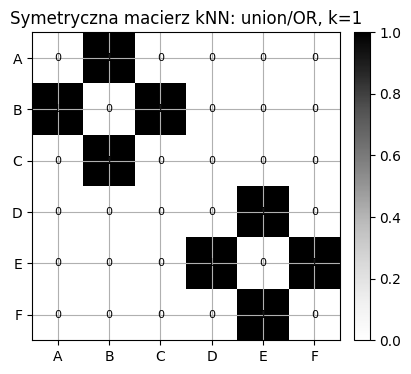

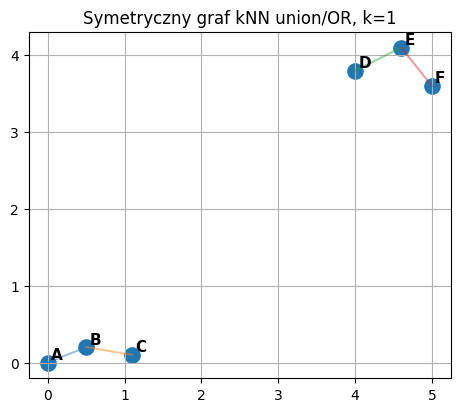

,A,B,C,D,E,F
A,.0f,.0f,.0f,.0f,.0f,.0f
B,.0f,.0f,.0f,.0f,.0f,.0f
C,.0f,.0f,.0f,.0f,.0f,.0f
D,.0f,.0f,.0f,.0f,.0f,.0f
E,.0f,.0f,.0f,.0f,.0f,.0f
F,.0f,.0f,.0f,.0f,.0f,.0f


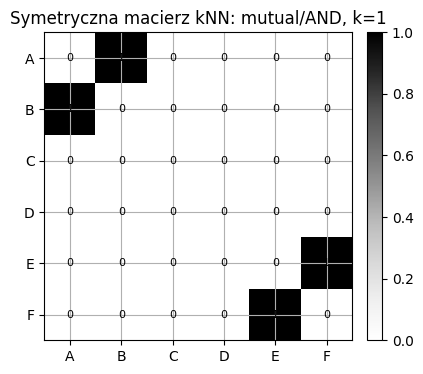

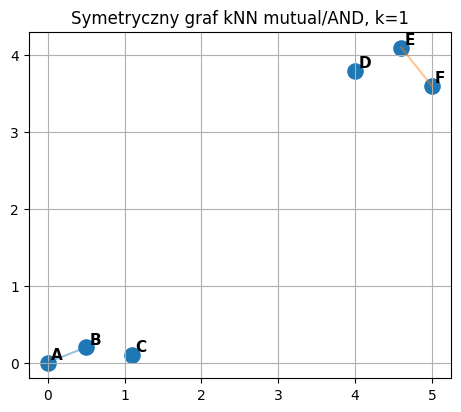

,A,B,C,D,E,F
A,.0f,.0f,.0f,.0f,.0f,.0f
B,.0f,.0f,.0f,.0f,.0f,.0f
C,.0f,.0f,.0f,.0f,.0f,.0f
D,.0f,.0f,.0f,.0f,.0f,.0f
E,.0f,.0f,.0f,.0f,.0f,.0f
F,.0f,.0f,.0f,.0f,.0f,.0f


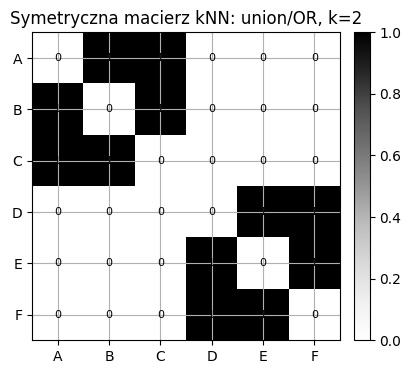

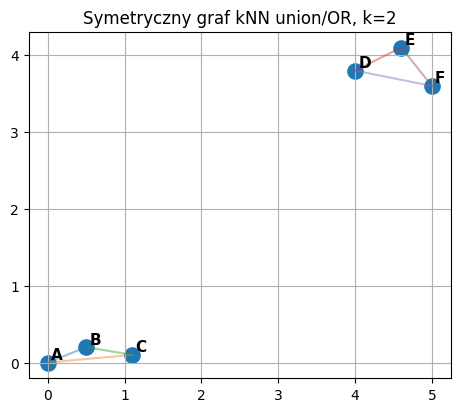

,A,B,C,D,E,F
A,.0f,.0f,.0f,.0f,.0f,.0f
B,.0f,.0f,.0f,.0f,.0f,.0f
C,.0f,.0f,.0f,.0f,.0f,.0f
D,.0f,.0f,.0f,.0f,.0f,.0f
E,.0f,.0f,.0f,.0f,.0f,.0f
F,.0f,.0f,.0f,.0f,.0f,.0f


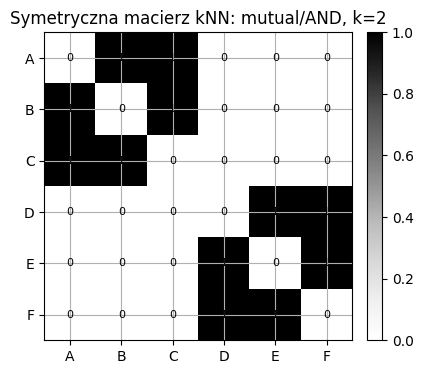

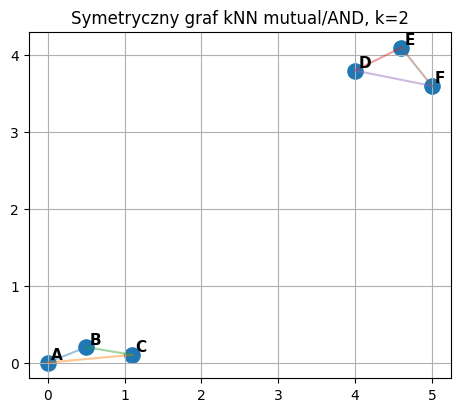

,A,B,C,D,E,F
A,.0f,.0f,.0f,.0f,.0f,.0f
B,.0f,.0f,.0f,.0f,.0f,.0f
C,.0f,.0f,.0f,.0f,.0f,.0f
D,.0f,.0f,.0f,.0f,.0f,.0f
E,.0f,.0f,.0f,.0f,.0f,.0f
F,.0f,.0f,.0f,.0f,.0f,.0f


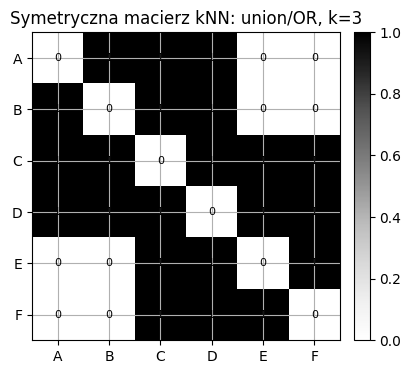

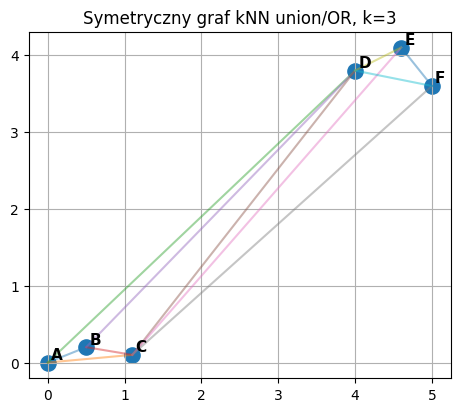

,A,B,C,D,E,F
A,.0f,.0f,.0f,.0f,.0f,.0f
B,.0f,.0f,.0f,.0f,.0f,.0f
C,.0f,.0f,.0f,.0f,.0f,.0f
D,.0f,.0f,.0f,.0f,.0f,.0f
E,.0f,.0f,.0f,.0f,.0f,.0f
F,.0f,.0f,.0f,.0f,.0f,.0f


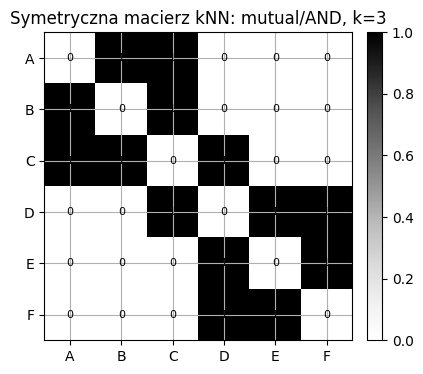

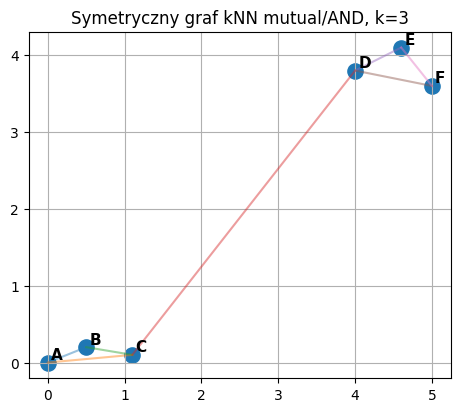

In [7]:
def sym_union(A):
    return np.maximum(A, A.T)

def sym_mutual(A):
    return np.minimum(A, A.T)

for k in [1,2,3]:
    A_dir = knn_adjacency(D, k)
    A_union = sym_union(A_dir)
    A_mutual = sym_mutual(A_dir)
    show_matrix(A_union, labels, f'Symetryczna macierz kNN: union/OR, k={k}', fmt='.0f', cmap='Greys', vmin=0, vmax=1)
    plot_graph(X, labels, A_union, title=f'Symetryczny graf kNN union/OR, k={k}', directed=False)
    plt.show()
    show_matrix(A_mutual, labels, f'Symetryczna macierz kNN: mutual/AND, k={k}', fmt='.0f', cmap='Greys', vmin=0, vmax=1)
    plot_graph(X, labels, A_mutual, title=f'Symetryczny graf kNN mutual/AND, k={k}', directed=False)
    plt.show()

## 6. Czy ostatnia macierz dla $k=3$ jest prawidłowa?

Tak — **jeżeli używamy symetryzacji union/OR**, ostatnia macierz jest prawidłowa.

Ale wygląda zaskakująco, bo mamy tylko 6 punktów i dwie grupy po 3 punkty:

$$
\{A,B,C\}, \qquad \{D,E,F\}.
$$

Jeśli ustawimy $k=3$, to każdy punkt musi wybrać **trzech** sąsiadów z pozostałych pięciu.  
W swojej lokalnej grupie ma tylko dwóch naturalnych sąsiadów, więc trzeci sąsiad musi już pochodzić z drugiej grupy.

Dlatego $k=3$ tworzy mosty między grupami.

To nie jest błąd kodu. To jest ważna lekcja:

> zbyt duże $k$ może połączyć regiony, które intuicyjnie powinny pozostać oddzielne.


Kierunkowa macierz kNN dla k=3


,A,B,C,D,E,F
A,0,1,1,1,0,0
B,1,0,1,1,0,0
C,1,1,0,1,0,0
D,0,0,1,0,1,1
E,0,0,1,1,0,1
F,0,0,1,1,1,0


Union/OR: krawędź istnieje, jeśli A wybiera B LUB B wybiera A


,A,B,C,D,E,F
A,0,1,1,1,0,0
B,1,0,1,1,0,0
C,1,1,0,1,1,1
D,1,1,1,0,1,1
E,0,0,1,1,0,1
F,0,0,1,1,1,0


Mutual/AND: krawędź istnieje, jeśli A wybiera B I B wybiera A


,A,B,C,D,E,F
A,0,1,1,0,0,0
B,1,0,1,0,0,0
C,1,1,0,1,0,0
D,0,0,1,0,1,1
E,0,0,0,1,0,1
F,0,0,0,1,1,0


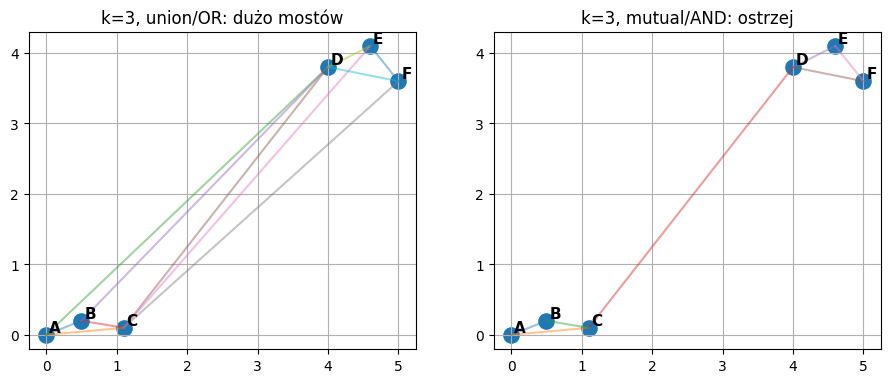

In [8]:
k = 3
A3 = knn_adjacency(D, k)
print('Kierunkowa macierz kNN dla k=3')
display(pd.DataFrame(A3, index=labels, columns=labels))
print('Union/OR: krawędź istnieje, jeśli A wybiera B LUB B wybiera A')
display(pd.DataFrame(sym_union(A3), index=labels, columns=labels))
print('Mutual/AND: krawędź istnieje, jeśli A wybiera B I B wybiera A')
display(pd.DataFrame(sym_mutual(A3), index=labels, columns=labels))

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
plot_graph(X, labels, sym_union(A3), title='k=3, union/OR: dużo mostów', ax=axes[0])
plot_graph(X, labels, sym_mutual(A3), title='k=3, mutual/AND: ostrzej', ax=axes[1])
plt.show()

## 7. Interaktywny panel: jak $\varepsilon$ i $k$ zmieniają graf?

To jest najlepszy moment na krótką demonstrację na żywo.

Pierwszy panel pokazuje graf $\varepsilon$-sąsiedztwa: przesuwamy próg $\varepsilon$ i obserwujemy, kiedy dwie lokalne grupy zaczynają się łączyć.

Drugi panel pokazuje graf kNN: zmieniamy $k$ i porównujemy symetryzację `union/OR` z `mutual/AND`.

Najważniejsze pytanie dla słuchaczy:

> czy parametr techniczny tylko „reguluje wykres”, czy faktycznie zmienia definicję lokalności?


In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

html_dir = Path('../html')
html_dir.mkdir(parents=True, exist_ok=True)

def edge_xy_for_plotly(X, A, directed=False):
    xs, ys = [], []
    n = A.shape[0]
    for i in range(n):
        for j in range(n):
            if i == j or A[i, j] == 0:
                continue
            if not directed and j <= i:
                continue
            xs.extend([X[i, 0], X[j, 0], None])
            ys.extend([X[i, 1], X[j, 1], None])
    return xs, ys

# Panel 1: epsilon-neighborhood -------------------------------------------------
eps_values = [0.6, 0.8, 1.0, 1.2, 2.0, 3.0, 5.0]
active_eps_idx = eps_values.index(1.2)

fig_eps = make_subplots(
    rows=1, cols=2,
    subplot_titles=('graf $\\varepsilon$-sąsiedztwa', 'macierz sąsiedztwa $A^{(\\varepsilon)}$'),
    specs=[[{'type': 'scatter'}, {'type': 'heatmap'}]],
    column_widths=[0.55, 0.45]
)

fig_eps.add_trace(
    go.Scatter(
        x=X[:, 0], y=X[:, 1], mode='markers+text', text=labels,
        textposition='top center', marker=dict(size=14), name='punkty', showlegend=False
    ),
    row=1, col=1
)

for idx, eps_value in enumerate(eps_values):
    A_eps = adjacency_eps(D, eps_value)
    xs, ys = edge_xy_for_plotly(X, A_eps, directed=False)
    visible = idx == active_eps_idx
    edge_count = int(A_eps.sum() // 2)
    fig_eps.add_trace(
        go.Scatter(
            x=xs, y=ys, mode='lines', name=f'krawędzie, eps={eps_value}',
            visible=visible, hoverinfo='skip', showlegend=False, line=dict(width=3)
        ),
        row=1, col=1
    )
    fig_eps.add_trace(
        go.Heatmap(
            z=A_eps, x=labels, y=labels, zmin=0, zmax=1,
            colorscale='Greys', showscale=False, visible=visible,
            hovertemplate='i=%{y}<br>j=%{x}<br>A=%{z}<extra></extra>'
        ),
        row=1, col=2
    )

steps = []
for idx, eps_value in enumerate(eps_values):
    A_eps = adjacency_eps(D, eps_value)
    edge_count = int(A_eps.sum() // 2)
    visible = [True] + [False] * (2 * len(eps_values))
    visible[1 + 2 * idx] = True
    visible[1 + 2 * idx + 1] = True
    steps.append(dict(
        method='update',
        label=str(eps_value),
        args=[{'visible': visible},
              {'title': f'Próg eps={eps_value}: liczba krawędzi={edge_count}'}]
    ))

fig_eps.update_layout(
    title='Próg eps definiuje, co znaczy „wystarczająco blisko”',
    sliders=[dict(active=active_eps_idx, currentvalue={'prefix': 'eps = '}, steps=steps)],
    height=520
)
fig_eps.update_xaxes(scaleanchor='y', scaleratio=1, row=1, col=1)
fig_eps.update_yaxes(autorange='reversed', row=1, col=2)
fig_eps.write_html(html_dir / '0_1_panel_eps_sasiedztwo.html', include_plotlyjs='cdn')
fig_eps.show()

# Panel 2: kNN union vs mutual ---------------------------------------------------
k_values = [1, 2, 3, 4]
active_k_idx = 1

fig_knn = make_subplots(
    rows=1, cols=2,
    subplot_titles=('symetryzacja union/OR', 'symetryzacja mutual/AND'),
    specs=[[{'type': 'scatter'}, {'type': 'scatter'}]],
    column_widths=[0.5, 0.5]
)

for col in [1, 2]:
    fig_knn.add_trace(
        go.Scatter(
            x=X[:, 0], y=X[:, 1], mode='markers+text', text=labels,
            textposition='top center', marker=dict(size=14), name='punkty', showlegend=False
        ),
        row=1, col=col
    )

for idx, k_value in enumerate(k_values):
    A_dir = knn_adjacency(D, k_value)
    A_union = sym_union(A_dir)
    A_mutual = sym_mutual(A_dir)
    visible = idx == active_k_idx
    for A_plot, col, variant in [(A_union, 1, 'union'), (A_mutual, 2, 'mutual')]:
        xs, ys = edge_xy_for_plotly(X, A_plot, directed=False)
        fig_knn.add_trace(
            go.Scatter(
                x=xs, y=ys, mode='lines', visible=visible,
                name=f'{variant}, k={k_value}', hoverinfo='skip', showlegend=False,
                line=dict(width=3)
            ),
            row=1, col=col
        )

steps = []
for idx, k_value in enumerate(k_values):
    A_dir = knn_adjacency(D, k_value)
    A_union = sym_union(A_dir)
    A_mutual = sym_mutual(A_dir)
    visible = [True, True] + [False] * (2 * len(k_values))
    visible[2 + 2 * idx] = True
    visible[2 + 2 * idx + 1] = True
    steps.append(dict(
        method='update',
        label=str(k_value),
        args=[{'visible': visible},
              {'title': f'k={k_value}: union ma {int(A_union.sum()//2)} krawędzi, mutual ma {int(A_mutual.sum()//2)} krawędzi'}]
    ))

fig_knn.update_layout(
    title='Ten sam graf kierunkowy kNN można inaczej symetryzować',
    sliders=[dict(active=active_k_idx, currentvalue={'prefix': 'k = '}, steps=steps)],
    height=520
)
fig_knn.update_xaxes(scaleanchor='y', scaleratio=1, row=1, col=1)
fig_knn.update_xaxes(scaleanchor='y2', scaleratio=1, row=1, col=2)
fig_knn.write_html(html_dir / '0_1_panel_knn_union_mutual.html', include_plotlyjs='cdn')
fig_knn.show()


### Jak połączyć to z następnymi metodami?

Po tej sekcji można bardzo naturalnie przejść dalej:

```text
Macierz odległości
        ↓
Macierz sąsiedztwa / graf
        ↓
KNN: głosowanie po sąsiadach
DBSCAN: gęstość w promieniu eps
UMAP: graf lokalnego sąsiedztwa
Spectral clustering: analiza macierzy/grafu
```

Najważniejsze jest to, że **KNN, DBSCAN i UMAP nie są trzema zupełnie osobnymi historiami**. Wszystkie zaczynają się od tej samej decyzji: jak z odległości zrobić sąsiedztwo.


## 8. Co zapamiętać?

- Macierz odległości mówi **jak daleko** są punkty.
- Macierz $\varepsilon$-sąsiedztwa mówi: **czy odległość mieści się w promieniu**.
- Macierz kNN mówi: **czy punkt jest wśród $k$ najbliższych sąsiadów**.
- Kierunkowa macierz kNN ma w każdym wierszu dokładnie $k$ jedynek.
- Symetryzacja union/OR może dodać dużo połączeń.
- Symetryzacja mutual/AND jest bardziej konserwatywna.
- Zbyt duże $k$ potrafi sztucznie połączyć oddzielne grupy.

To jest dokładnie fundament pod UMAP, DBSCAN, KNN i późniejsze metody grafowe.
